In [13]:
import sys
import os
import glob
from scipy import stats

import dabest

import numpy as np
import scipy as sp
import pandas as pd
import math
import decimal

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Helvetica'
rcParams['font.size'] = 8 

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [15]:
filedir = "F:\\Opto\\eOPN3\\07.11.25\\ACR1 eOPN3 MIP Posterior vs Anterior.csv"

df=pd.read_csv(filedir)

df1 = df.iloc[0:36,0:4]
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

df1

,Genotype,Position,Value,ID,Genotype_Position
0,ACR1,Posterior,109.786,1,ACR1 Posterior
1,ACR1,Posterior,87.934,2,ACR1 Posterior
2,ACR1,Posterior,186.003,3,ACR1 Posterior
3,ACR1,Posterior,163.280,4,ACR1 Posterior
4,ACR1,Posterior,125.660,5,ACR1 Posterior
5,ACR1,Posterior,139.406,6,ACR1 Posterior
6,ACR1,Posterior,122.583,7,ACR1 Posterior
7,ACR1,Posterior,145.469,8,ACR1 Posterior
8,ACR1,Anterior,138.904,1,ACR1 Anterior
9,ACR1,Anterior,114.003,2,ACR1 Anterior


In [16]:
paired_delta2 = dabest.load(data = df1, x = ["Position", "Genotype"], y = "Value", delta2 = True, experiment = "Genotype", x1_level = ["Posterior", "Anterior"], paired = 'baseline', id_col = "ID" )
paired_delta2

DABEST v2025.10.17
                  
Good afternoon!
The current time is Mon Nov 17 17:12:01 2025.

Paired effect size(s) for repeated measures against baseline 
with 95% confidence intervals will be computed for:
1. Anterior ACR1 minus Posterior ACR1
2. Anterior eOPN3 minus Posterior eOPN3
3. eOPN3 minus ACR1 (only for mean difference)

5000 resamples will be used to generate the effect size bootstraps.

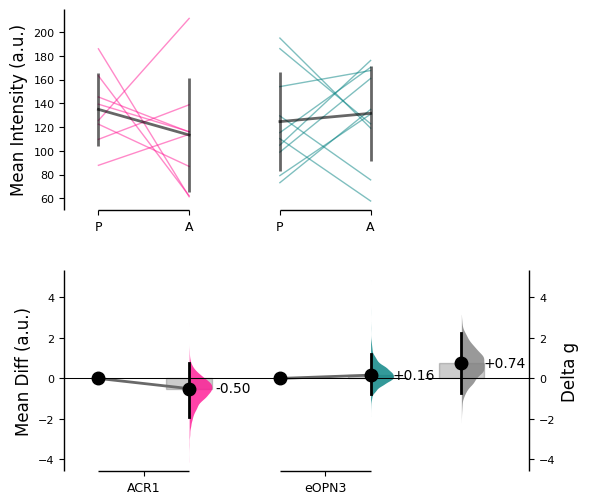

In [17]:
palette = { 'ACR1':'deeppink', 'eOPN3' : 'teal'}
genoListNL = [ 'ACR1','eOPN3']

compare = paired_delta2.hedges_g.plot(fontsize_rawxlabel=9,fontsize_contrastxlabel= 9,  color_col='Genotype', custom_palette=palette,  raw_desat=1, contrast_desat=1);



compare.axes[0].set_xticklabels(["P", "A",
                              "P", "A",])
compare.axes[0].set_ylabel('Mean Intensity (a.u.)')
compare.axes[1].set_ylabel('Mean Diff (a.u.)')
compare.axes[0].get_legend().remove()
compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels('')
compare.axes[1].set_xticklabels(genoListNL, fontsize = 9)



for i in range(len(genoListNL)):
     compare.axes[1].collections[i].set_color(palette[genoListNL[i]])
    

plt.show()
#compare.savefig('MB247ACR1 eOPN3.png', dpi = 300)
#compare.savefig('MB247ACR1 eOPN3.svg')


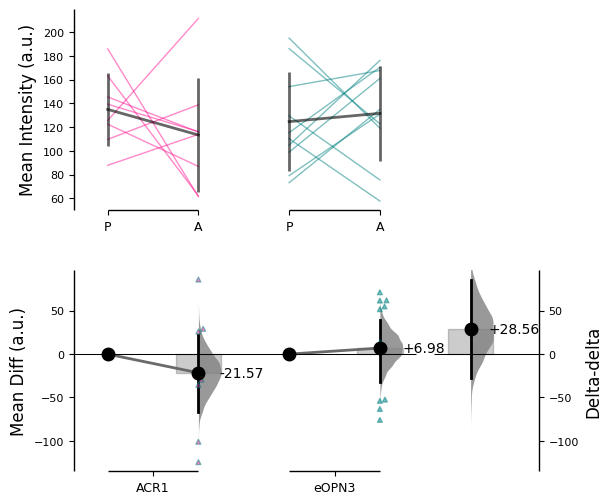

In [18]:
palette = { 'ACR1':'deeppink', 'eOPN3' : 'teal'}
genoListNL = [ 'ACR1','eOPN3']

compare = paired_delta2.mean_diff.plot(fontsize_rawxlabel=9,fontsize_contrastxlabel= 9,  color_col='Genotype', custom_palette=palette,  raw_desat=1, contrast_desat=1);



compare.axes[0].set_xticklabels(["P", "A",
                              "P", "A",])
compare.axes[0].set_ylabel('Mean Intensity (a.u.)')
compare.axes[1].set_ylabel('Mean Diff (a.u.)')
compare.axes[0].get_legend().remove()
compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels('')
compare.axes[1].set_xticklabels(genoListNL, fontsize = 9)



for i in range(len(genoListNL)):
     compare.axes[1].collections[i].set_color(palette[genoListNL[i]])
    

plt.show()
#compare.savefig('MB247ACR1 eOPN3.png', dpi = 300)
#compare.savefig('MB247ACR1 eOPN3.svg')


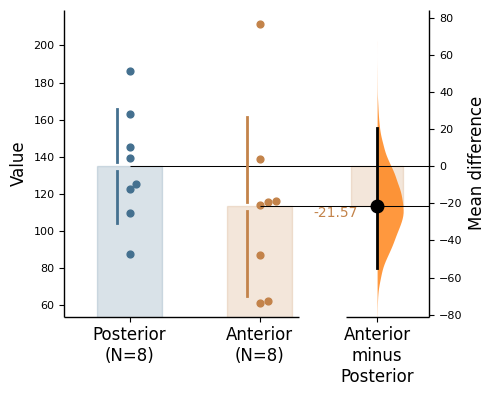

In [12]:
paired_delta2 = dabest.load(data = df1,  y = "Value", x = "Position", idx = ["Posterior", "Anterior"] )
paired_delta2.mean_diff.plot();